In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import logging
import os
import sys
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors

In [2]:
file_paths = {}
file_paths['wy03'] = '/bsuscratch/stanleyakor/nscid/wy/wy2003/sca_full_20021001_20030930.nc'
file_paths['wy04'] = '/bsuscratch/stanleyakor/nscid/wy/wy2004/sca_full_20031001_20040930.nc'
file_paths['wy05'] = '/bsuscratch/stanleyakor/nscid/wy/wy2005/sca_full_20041001_20050930.nc'
file_paths['wy06'] = '/bsuscratch/stanleyakor/nscid/wy/wy2006/sca_full_20051001_20060930.nc'
file_paths['wy07'] = '/bsuscratch/stanleyakor/nscid/wy/wy2007/sca_full_20061001_20070930.nc'
file_paths['wy08'] = '/bsuscratch/stanleyakor/nscid/wy/wy2008/sca_full_20071001_20080930.nc'
file_paths['wy09'] = '/bsuscratch/stanleyakor/nscid/wy/wy2009/sca_full_20081001_20090930.nc'
file_paths['wy10'] = '/bsuscratch/stanleyakor/nscid/wy/wy2010/sca_full_20091001_20100930.nc'
file_paths['wy11'] = '/bsuscratch/stanleyakor/nscid/wy/wy2011/sca_full_20101001_20110930.nc'
file_paths['wy12'] = '/bsuscratch/stanleyakor/nscid/wy/wy2012/sca_full_20111001_20120930.nc'
file_paths['wy13'] = '/bsuscratch/stanleyakor/nscid/wy/wy2013/sca_full_20121001_20130930.nc'
file_paths['wy14'] = '/bsuscratch/stanleyakor/nscid/wy/wy2014/sca_full_20131001_20140930.nc'
file_paths['wy15'] = '/bsuscratch/stanleyakor/nscid/wy/wy2015/sca_full_20141001_20150930.nc'
file_paths['wy16'] = '/bsuscratch/stanleyakor/nscid/wy/wy2016/sca_full_20151001_20160930.nc'
file_paths['wy17'] = '/bsuscratch/stanleyakor/nscid/wy/wy2017/sca_full_20161001_20170930.nc'

In [3]:
def monthly_cloud_fraction_from_file(nc_path, var_name='NDSI_Snow_Cover', time_name="time"):
    """
    Count-based monthly cloud fraction (%) for a WY file:
      cloud% = 100 * (#NaN over all days+pixels in month) / (total #pixels in month)

    Returns: list of 12 floats in Oct->Sep order.
    """
    ds = xr.open_dataset(nc_path)

    if var_name is None:
        var_name = list(ds.data_vars)[0]
    da = ds[var_name]

    
    t = pd.to_datetime(da[time_name].values)

   
    t0 = t[0]
    wy_start_year = t0.year if t0.month >= 10 else t0.year - 1
    wy_start = pd.Timestamp(wy_start_year, 10, 1)
    months = pd.date_range(wy_start, wy_start + pd.DateOffset(months=11), freq="MS")

    out = []
    for m0 in months:
        m1 = m0 + pd.DateOffset(months=1)

        # slice this month
        da_m = da.sel({time_name: slice(m0, m1 - pd.Timedelta("1ns"))})

        # total pixels in month = (#timesteps) * (product of spatial dims)
        total = da_m.size
        cloudy = int(da_m.isnull().sum().values)

        out.append(100.0 * cloudy / total if total > 0 else np.nan)

    ds.close()
    return out


In [4]:
pdict = {}
for key,value in file_paths.items():
    print(key)
    monthly = monthly_cloud_fraction_from_file(value)
    pdict[key] = monthly
    

wy03
wy04
wy05
wy06
wy07
wy08
wy09
wy10
wy11
wy12
wy13
wy14
wy15
wy16
wy17


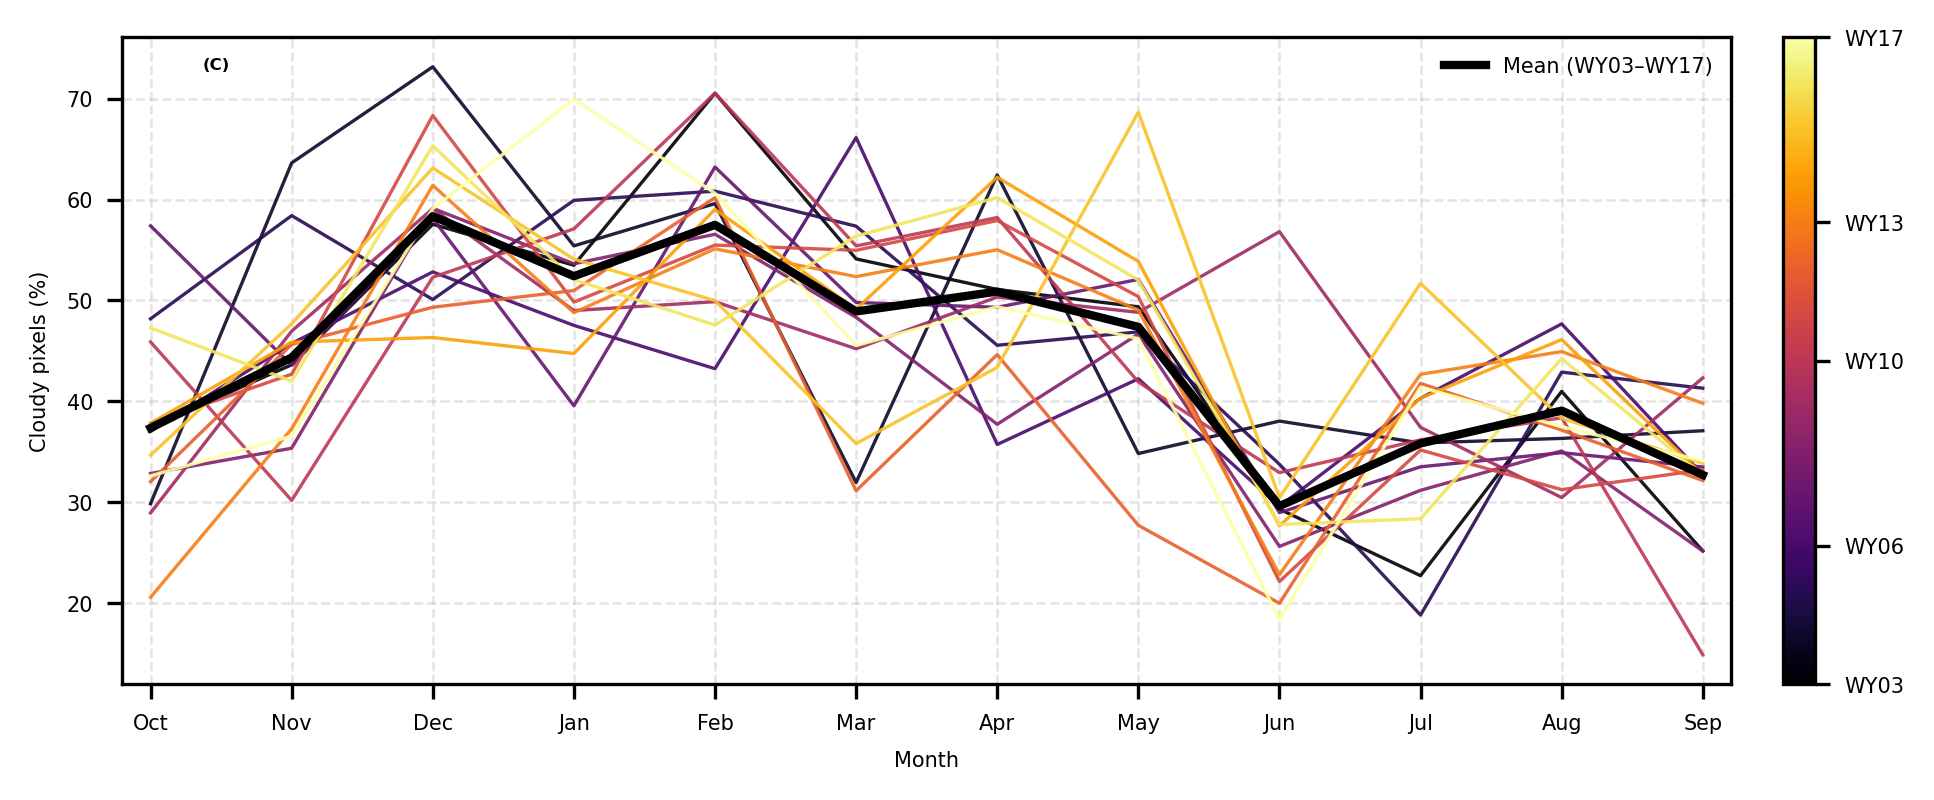

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 2.8), dpi=300)
def plot_cloud_frac(ax,cmap, label, lims):
    months = ["Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep"]
    x = np.arange(len(months))
    
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    
    # ---- data prep ----
    keys = sorted(pdict.keys(), key=lambda k: int(k.replace("wy","")))
    years = np.array([int(k.replace("wy","")) for k in keys])
    Y = np.array([pdict[k] for k in keys], dtype=float)
    mean_line = np.nanmean(Y, axis=0)
    
    # ---- colormap + normalization ----
    cmap = plt.get_cmap(cmap)  
    norm = mpl.colors.Normalize(vmin=years.min(), vmax=years.max())
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    
    
    
    # ---- WY lines (colored by WY via colorbar) ----
    for k, y in zip(keys, years):
        ax.plot(
            x,
            pdict[k],
            color=cmap(norm(y)),
            lw=.8,
            alpha=0.9
        )
    
    # ---- mean line (visual anchor) ----
    ax.plot(
        x,
        mean_line,
        color="black",
        lw=2.,
        label="Mean (WY03–WY17)"
    )
    
    # ---- axes formatting ----
    ax.set_xticks(x)
    ax.set_xticklabels(months)
    ax.set_xlim(-0.2, len(months) - 0.8)
    ax.set_ylabel("Cloudy pixels (%)",fontsize=5)
    ax.set_xlabel("Month",fontsize=5)
    ax.tick_params(axis="both", labelsize=5)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    
    # Mean-only legend (small, unobtrusive)
    ax.legend(fontsize=5, frameon=False)
    ax.text(lims[0], lims[-1], label, transform=ax.transAxes, fontsize=4, color='black', weight='bold')
    # ---- colorbar as legend for WY ----
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.03)
    # cbar.set_label("Water year")
    cbar.set_ticks([years.min(), years.min()+3 ,10, 13,years.max()])
    cbar.set_ticklabels([f"WY{years.min():02d}", f"WY{years.min() +3:02d}","WY10", "WY13",f"WY{years.max():02d}"])
    cbar.ax.tick_params(labelsize=5)
    
    # fig.subplots_adjust(left=0.07, right=0.90, bottom=0.18, top=0.92)
    # plt.show()
plot_cloud_frac(ax,cmap = 'inferno', label = '(C)', lims = (0.05, .95))

In [6]:
def plot_snow_mask_panel(
    ax,
    geog_ds,
    time_index,
    label,
    lims,
    diff=0.45,
    variable = 'snow_mask',
    axis_y = True,
    cbar = True
):
    """
    Plot categorical snow mask on a given axis.

    Categories:
      0   -> No snow
      1   -> Snow
      NaN -> Cloud
    """

    
    # order corresponds to [0, 1, NaN]
#     colors = [
#     "#a6611a",  # 0 = no snow (earth/brown)
#     "#ffffff",  # 1 = snow (white)
#     "#4c72b0",  # NaN = cloud (blue-gray)
# ]

    colors = [
    "#FFC20A",  # 0 = no snow (earth/brown)
    "#0C7DBC",  # 1 = snow (white)
    "white",  # NaN = cloud (blue-gray)
    ]

    # Map values to indices: 0->0, 1->1, NaN->2
    snow = geog_ds[variable].isel(time=time_index).values
    plot_data = np.full_like(snow, 2, dtype=float)  # default = cloud
    plot_data[snow == 0] = 0
    plot_data[snow == 1] = 1

    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    im = ax.imshow(
        plot_data,
        extent=(
            geog_ds.lon.min(),
            geog_ds.lon.max(),
            geog_ds.lat.min(),
            geog_ds.lat.max(),
        ),
        cmap=cmap,
        norm=norm,
        origin="upper",
        alpha=1.0,
    )

    # ---- ticks ----
    ax.set_xticks(
        np.linspace(
            geog_ds.lon.min().values + diff,
            geog_ds.lon.max().values - diff,
            4,
        )
    )
    ax.set_yticks(
        np.linspace(
            geog_ds.lat.min().values + diff,
            geog_ds.lat.max().values - diff,
            4,
        )
    )

    lon_ticks = ax.get_xticks()
    lat_ticks = ax.get_yticks()

    lon_labels = [f"{abs(lon):.1f}°{'W' if lon < 0 else 'E'}" for lon in lon_ticks]
    lat_labels = [f"{abs(lat):.1f}°{'S' if lat < 0 else 'N'}" for lat in lat_ticks]

    ax.set_xticklabels(lon_labels)
    ax.set_yticklabels(lat_labels)
    ax.tick_params(axis="both", labelsize=5)

    ax.text(lims[0], lims[-1], label, transform=ax.transAxes, fontsize=4, color='black', weight='bold')

    if axis_y == False:
        ax.set_yticklabels([''] * len(ax.get_xticks()))

    if cbar ==True:
        # ---- categorical colorbar ----
        cbar = plt.colorbar(
            im,
            ax=ax,
            fraction=0.04,
            pad=0.02,
            ticks=[0, 1, 2],
        )
        cbar.ax.set_yticklabels(["No snow", "Snow", "Cloud"])
        cbar.ax.tick_params(labelrotation=90)
        cbar.ax.tick_params(labelsize=4)


    return im


In [7]:
def make_three_panel_layout(
    imgA, imgB,                
    pdict,                     
    months=("Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep"),
    cmap_imshow="viridis",
    cmap_lines="cividis",       
    add_mean=True,
):
    
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "legend.fontsize": 7.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

    fig = plt.figure(figsize=(4.6, 3.8), dpi=300)
    gs = fig.add_gridspec(
        nrows=2, ncols=2,
        height_ratios=[2.0, 1.5],  # top panels taller, bottom shorter
        width_ratios=[1.0, 1.0],
        hspace=0.2, wspace=0.1
    )

    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[1, :])  # span both columns

    # # -------------------------
    # # Panel A (imshow)
    # # -------------------------

    plot_snow_mask_panel(
    ax=axA,
    geog_ds=imgA,
    time_index=182,
    label = '(A)',
    lims = (0.05, .95),
     cbar = False
    )

    # # -------------------------
    # # Panel B (imshow)
    # # -------------------------

    plot_snow_mask_panel(
    ax=axB,
    geog_ds=imgB,
    time_index=182,
    label = '(B)',
    lims = (0.05, 0.95),
    variable = 'NDSI_Snow_Cover',
    axis_y = False,
   
    )
    # -------------------------
    # Panel C (monthly lines)
    # -------------------------
    plot_cloud_frac(axC,cmap = 'cividis',label = '(C)',lims = (0.05, .95))
    return fig, (axA, axB, axC)

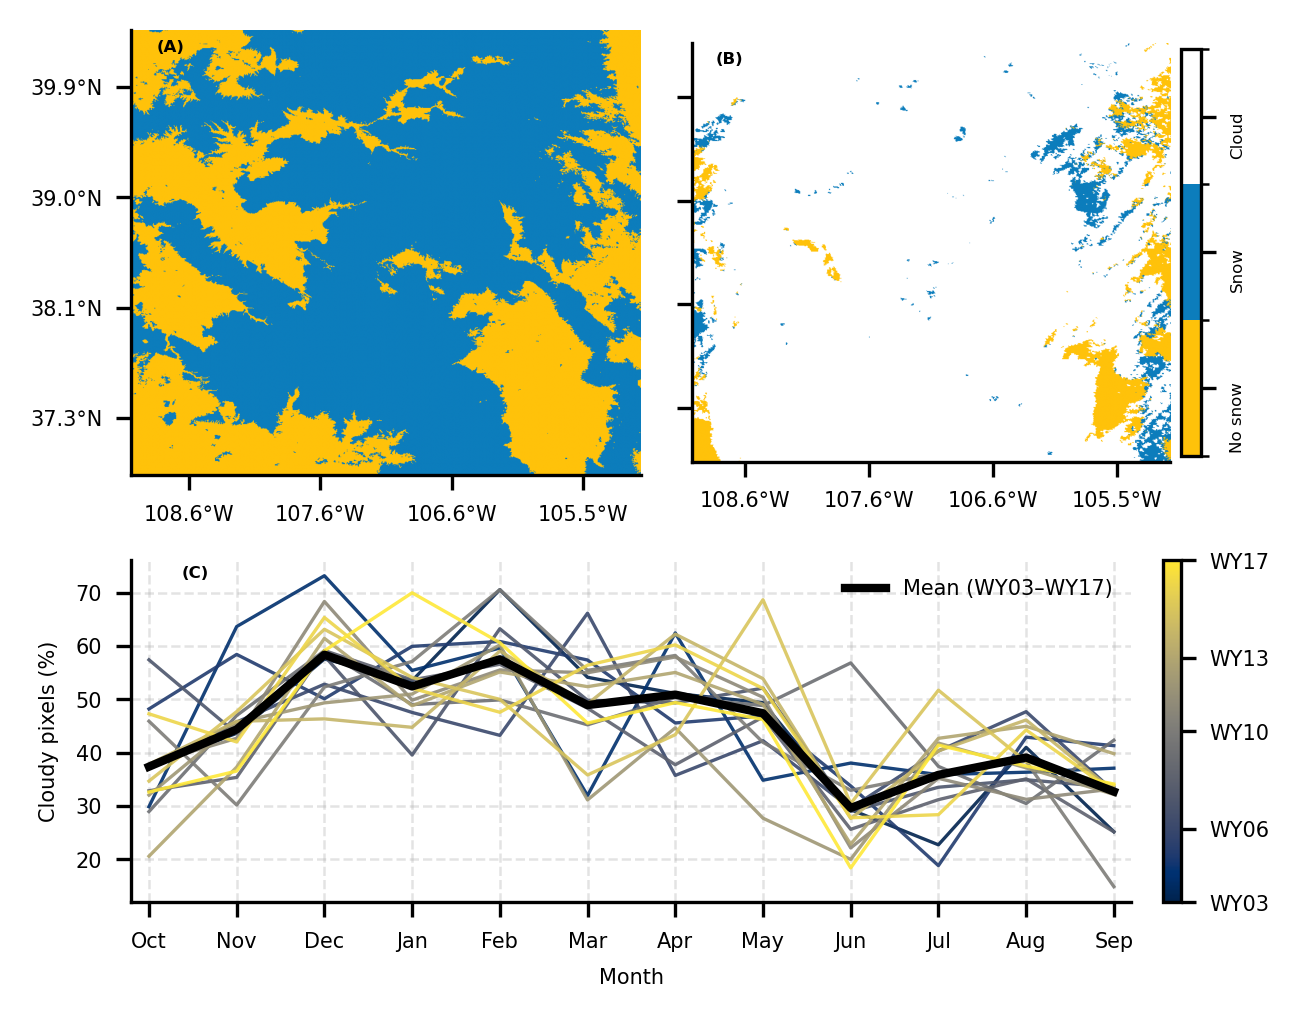

In [9]:

imgA = xr.open_dataset(
    "/bsuscratch/stanleyakor/nscid/wy/wy2010/cloud_corrected_snow_data_wy2010.nc"
    
 )
imgB = xr.open_dataset(
    file_paths['wy10']
    
 )
fig, axes = make_three_panel_layout(imgA, imgB, pdict, cmap_lines="viridis")
plt.savefig('a.pdf')
plt.show()